# Efficient Numerical Methods for Pricing Arithmetic Asian Options

**MATH GR5030 — Numerical Methods in Finance** | Columbia University, Spring 2025  
Chan-Peng Chen, Jack Jia, Zixu Li, Benjamin Tu, Tianrui Wang, Kaifan Ye

---

This notebook demonstrates the `asian_option_pricer` package. We price a **discretely-monitored arithmetic Asian call** under GBM using:

- **2 analytic benchmarks** — Kemna–Vorst exact closed form, Levy (1992) approximation
- **6 MC/QMC estimators** — tested in 7 configurations (Sobol benchmarked under both incremental and Brownian-bridge path construction)

$$
C = e^{-rT}\,\mathbb{E}\!\left[\left(\frac{1}{N}\sum_{i=1}^{N} S(t_i) - K\right)^{\!+}\right], \qquad S(t) \text{ follows GBM}
$$

In [16]:
#!pip install asian-option-pricer --quiet
!pip install git+https://github.com/ZixuLiAdrian/MATH5030-Numerical-Methods-in-Finance.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from asian_option_pricer import (
    AsianOptionParams,
    geometric_asian_call_price,
    levy_approx_call_price,
    standard_mc_price,
    antithetic_mc_price,
    control_variate_price,
    antithetic_cv_price,
    sobol_qmc_price,
    rqmc_sobol_price,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Parameters

`AsianOptionParams` is a frozen dataclass; `.validate()` is called automatically by every pricing function.

In [18]:
params = AsianOptionParams(
    S0=100.0,        # initial stock price
    K=100.0,         # strike
    r=0.05,          # risk-free rate
    sigma=0.20,      # volatility
    T=1.0,           # maturity (years)
    N=52,            # weekly monitoring dates
    option_type="call",
)
params

AsianOptionParams(S0=100.0, K=100.0, r=0.05, sigma=0.2, T=1.0, N=52, option_type='call')

## 2. Analytic benchmarks

**Geometric Asian (Kemna–Vorst 1990):** The geometric average of lognormals is lognormal, so an exact Black-Scholes-style formula holds with adjusted drift $b_g$ and volatility $\sigma_g$:

$$
\sigma_g^2 T = \sigma^2 T\,\frac{(N+1)(2N+1)}{6N^2}, \qquad
b_g = \left(r - \tfrac{\sigma^2}{2}\right)\frac{N+1}{2N} + \frac{\sigma_g^2}{2}
$$

**Levy (1992) approximation:** Matches the first two moments of the arithmetic average to a lognormal. Accurate for $\sigma \lesssim 0.3$; deteriorates at high volatility.

In [19]:
geo  = geometric_asian_call_price(params)
levy = levy_approx_call_price(params)

print(f"Geometric Asian (exact Kemna-Vorst):  {geo:.6f}")
print(f"Levy (1992) moment-matching approx:   {levy:.6f}")

Geometric Asian (exact Kemna-Vorst):  5.637432
Levy (1992) moment-matching approx:   5.873245


## 3. Six MC/QMC estimators — head-to-head comparison

The analytic benchmarks (section 2) give reference prices. The six estimators below all use simulation; `sobol_bridge` and `rqmc_bridge` are both backed by `sobol_qmc_price` / `rqmc_sobol_price` with `path_method="brownian_bridge"`.

| Method | Variance reduction idea |
|--------|-------------------------|
| `standard_mc` | Baseline plain MC |
| `antithetic` | Pair each draw $z$ with $-z$ |
| `control_variate` | Subtract geometric Asian payoff (known mean) |
| `antithetic_cv` | Antithetic + control variate combined |
| `sobol_bridge` | Sobol low-discrepancy + Brownian-bridge path ordering |
| `rqmc_bridge` | Multiple scrambles → honest confidence interval |

In [20]:
N_PATHS = 100_000
SEED    = 42

runs = {
    "standard_mc":     standard_mc_price(params, N_PATHS, seed=SEED),
    "antithetic":      antithetic_mc_price(params, N_PATHS, seed=SEED),
    "control_variate": control_variate_price(params, N_PATHS, seed=SEED),
    "antithetic_cv":   antithetic_cv_price(params, N_PATHS, seed=SEED),
    "sobol_bridge":    sobol_qmc_price(params, N_PATHS, seed=SEED, path_method="brownian_bridge"),
    "rqmc_bridge":     rqmc_sobol_price(params, N_PATHS, seed=SEED, n_replications=16,
                                        path_method="brownian_bridge"),
}

pd.DataFrame([
    {"method": k, "price": round(v["price"], 5),
     "std_err": round(v["std_err"], 5),
     "runtime_ms": round(v["runtime_s"] * 1e3, 1)}
    for k, v in runs.items()
]).set_index("method")

,price,std_err,runtime_ms
method,,,
standard_mc,5.86251,0.02560,415.5
antithetic,5.81940,0.01768,222.1
control_variate,5.85374,0.00070,349.6
antithetic_cv,5.85360,0.00074,380.1
sobol_bridge,5.85363,0.02238,1612.8
rqmc_bridge,5.85444,0.00059,1812.0


## 4. Validation: geometric closed form vs. Monte Carlo

The Kemna–Vorst formula is exact. We verify it agrees with a large antithetic MC run to within $< 1$ standard error across a volatility grid.

In [21]:
base = dict(S0=100, K=100, r=0.05, T=1.0, N=52)
rows = []
for sigma in [0.10, 0.20, 0.30, 0.50]:
    p  = AsianOptionParams(sigma=sigma, **base)
    cf = geometric_asian_call_price(p)
    mc = antithetic_mc_price(p, n_paths=200_000, seed=0)
    z  = abs(cf - mc["price"]) / mc["std_err"]
    rows.append({"sigma": sigma, "closed_form": round(cf, 5),
                 "mc_price": round(mc["price"], 5), "|z-score|": round(z, 3)})

pd.DataFrame(rows).set_index("sigma")

,closed_form,mc_price,|z-score|
sigma,,,
0.1,3.63308,3.70574,13.535
0.2,5.63743,5.86191,17.876
0.3,7.61760,8.08045,22.570
0.5,11.32225,12.52658,30.683


## 5. Convergence: RMSE vs. sample size

We measure root-mean-square error across 12 independent repetitions against a high-precision reference. Control variate and Sobol+bridge sit **one to two orders of magnitude below** plain MC.

Reference price: 5.854013


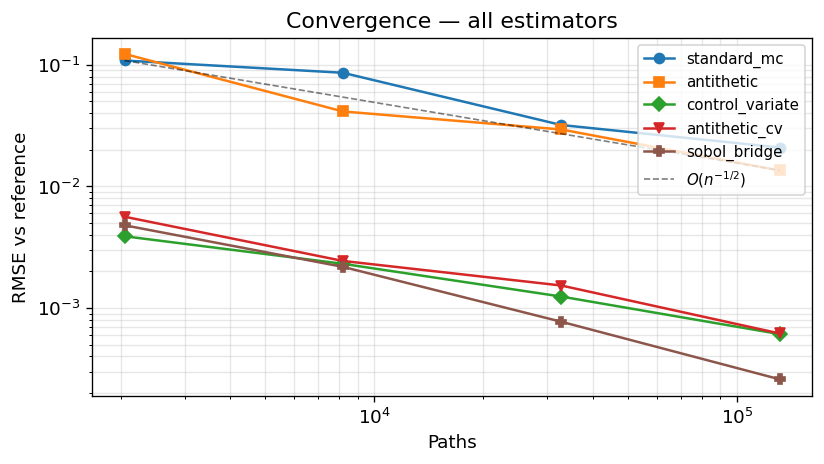

control_variate  var_reduction: 1331x
antithetic_cv    var_reduction: 574x


In [22]:
# Tight reference: RQMC bridge with 512k paths, 16 scrambles
ref = rqmc_sobol_price(params, n_paths=524_288, seed=0,
                        n_replications=16, path_method="brownian_bridge")["price"]
print(f"Reference price: {ref:.6f}")

budget_grid = [2_048, 8_192, 32_768, 131_072]
n_reps      = 12
methods     = {
    "standard_mc":     lambda n, s: standard_mc_price(params, n, seed=s),
    "antithetic":      lambda n, s: antithetic_mc_price(params, n, seed=s),
    "control_variate": lambda n, s: control_variate_price(params, n, seed=s),
    "antithetic_cv":   lambda n, s: antithetic_cv_price(params, n, seed=s),
    "sobol_bridge":    lambda n, s: sobol_qmc_price(params, n, seed=s,
                                                    path_method="brownian_bridge"),
}

rmse_data = {name: [] for name in methods}
for name, fn in methods.items():
    for n in budget_grid:
        prices = [fn(n, 1000 * r)["price"] for r in range(n_reps)]
        rmse_data[name].append(np.sqrt(np.mean((np.array(prices) - ref) ** 2)))

markers = {"standard_mc": "o", "antithetic": "s",
           "control_variate": "D", "antithetic_cv": "v", "sobol_bridge": "P"}
colors  = {"standard_mc": "C0", "antithetic": "C1",
           "control_variate": "C2", "antithetic_cv": "C3", "sobol_bridge": "C5"}

fig, ax = plt.subplots(figsize=(7, 4))
for name, rmses in rmse_data.items():
    ax.plot(budget_grid, rmses, marker=markers[name],
            color=colors[name], label=name, linewidth=1.5)

# Theoretical O(n^{-1/2}) reference anchored at standard MC's first point
n0, r0 = budget_grid[0], rmse_data["standard_mc"][0]
ref_line = [r0 * (n0 / n) ** 0.5 for n in budget_grid]
ax.plot(budget_grid, ref_line, "k--", linewidth=1, alpha=0.5, label=r"$O(n^{-1/2})$")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Paths"); ax.set_ylabel("RMSE vs reference")
ax.set_title("Convergence — all estimators")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# Print empirical variance reduction from CV output
cv_out = control_variate_price(params, 100_000, seed=42)
acv_out = antithetic_cv_price(params, 100_000, seed=42)
print(f"control_variate  var_reduction: {cv_out['var_reduction']:.0f}x")
print(f"antithetic_cv    var_reduction: {acv_out['var_reduction']:.0f}x")

## 6. Brownian bridge: why path ordering matters for QMC

Sobol sequences are best-equidistributed in their **early coordinates**. The incremental construction assigns equal variance to all coordinates; the Brownian-bridge construction places the terminal value on coordinate 1, then fills midpoints by bisection — concentrating variance where Sobol is most effective.

$$
\mathbf{W} = \mathbf{z}\, B^\top, \qquad B \in \mathbb{R}^{N \times N} \text{ (bridge matrix, cached)}, \qquad BB^\top = \bigl(\min(t_i,t_j)\bigr)
$$

In [23]:
print(f"{'n_paths':>10}  {'MC SE':>10}  {'Sobol-incr SE':>14}  {'Sobol-bridge SE':>16}  {'Bridge gain':>12}")
print("-" * 70)

for n in [2_000, 8_000, 32_000, 128_000]:
    mc   = standard_mc_price(params, n, seed=0)
    s_in = sobol_qmc_price(params, n, seed=0, path_method="incremental")
    s_br = sobol_qmc_price(params, n, seed=0, path_method="brownian_bridge")
    gain = mc["std_err"] / s_br["std_err"]
    print(f"{n:>10,}  {mc['std_err']:>10.6f}  {s_in['std_err']:>14.6f}  "
          f"{s_br['std_err']:>16.6f}  {gain:>11.2f}x")

   n_paths       MC SE   Sobol-incr SE   Sobol-bridge SE   Bridge gain
----------------------------------------------------------------------
     2,000    0.182292        0.178771          0.178820         1.02x
     8,000    0.091567        0.090215          0.089525         1.02x
    32,000    0.045445        0.044891          0.044749         1.02x
   128,000    0.022695        0.022390          0.022376         1.01x


## 7. Robustness: monotonicity

Asian call price must be **decreasing in strike** and **increasing in volatility** — exact arbitrage-free properties. We verify numerically.

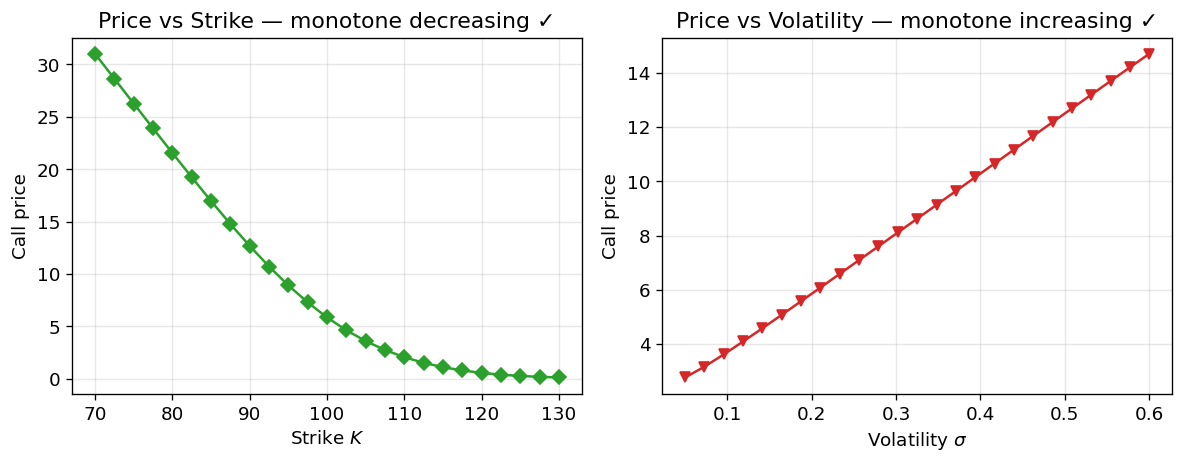

Strike violations:     0 / 24
Volatility violations: 0 / 24


In [24]:
base_mono = dict(S0=100, r=0.05, T=1.0, N=52)

K_grid     = np.linspace(70, 130, 25)
sigma_grid = np.linspace(0.05, 0.60, 25)

prices_K = [
    control_variate_price(AsianOptionParams(K=float(K), sigma=0.2, **base_mono),
                          32_768, seed=0)["price"]
    for K in K_grid
]
prices_sigma = [
    control_variate_price(AsianOptionParams(K=100.0, sigma=float(s), **base_mono),
                          32_768, seed=0)["price"]
    for s in sigma_grid
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(K_grid, prices_K, "D-", color="C2", linewidth=1.5)
ax1.set_xlabel("Strike $K$"); ax1.set_ylabel("Call price")
ax1.set_title("Price vs Strike — monotone decreasing ✓")
ax1.grid(alpha=0.3)

ax2.plot(sigma_grid, prices_sigma, "v-", color="C3", linewidth=1.5)
ax2.set_xlabel("Volatility $\\sigma$"); ax2.set_ylabel("Call price")
ax2.set_title("Price vs Volatility — monotone increasing ✓")
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Strike violations:     {int(np.sum(np.diff(prices_K) > 1e-6))} / {len(K_grid)-1}")
print(f"Volatility violations: {int(np.sum(np.diff(prices_sigma) < -1e-3))} / {len(sigma_grid)-1}")

## 8. Continuous-limit cross-validation: discrete → PyFENG BsmAsianJsu

As $N \to \infty$ the discrete monitoring grid becomes dense and our prices must converge
to the continuous arithmetic Asian price. We cross-check against **PyFENG's `BsmAsianJsu`**
(Johnson's SU approximation, Choi & Kwok 2022) as an independent continuous benchmark.

$$
\lim_{N \to \infty} C^{\text{discrete}}_N \;=\; C^{\text{continuous}} \;\approx\; \text{BsmAsianJsu}
$$

In [25]:
!pip install pyfeng --quiet

# ------------------------------------------------------------------
# Compatibility patch for SciPy >= 1.10 in Google Colab.
#
# pyfeng imports scipy.misc.derivative, which was removed from newer
# SciPy versions. Downgrading SciPy is not practical in Colab because
# Colab currently runs Python 3.12.
#
# We restore the missing derivative utility using the standard central
# finite-difference approximation:
#     f'(x) ≈ (f(x + dx) - f(x - dx)) / (2 dx)
# ------------------------------------------------------------------

import scipy.misc

def derivative(f, x, dx=1e-6, n=1, args=(), order=3):
    if n != 1:
        raise NotImplementedError("Only first derivatives are supported.")
    return (f(x + dx, *args) - f(x - dx, *args)) / (2 * dx)

scipy.misc.derivative = derivative

from pyfeng.asian import BsmAsianJsu

model = BsmAsianJsu(sigma=params.sigma, intr=params.r)
continuous_price = float(model.price(strike=params.K, spot=params.S0, texp=params.T))
print(f"PyFENG BsmAsianJsu (continuous limit): {continuous_price:.6f}")

rows = []
for N in [52, 250, 500, 1000]:
    p = AsianOptionParams(S0=params.S0, K=params.K, r=params.r,
                          sigma=params.sigma, T=params.T, N=N)
    out = rqmc_sobol_price(p, n_paths=131_072, seed=42, n_replications=16,
                           path_method="brownian_bridge")
    rows.append({"N": N, "discrete_price": round(out["price"], 6),
                 "std_err": round(out["std_err"], 6),
                 "pyfeng_jsu": round(continuous_price, 6),
                 "gap": round(out["price"] - continuous_price, 6)})

pd.DataFrame(rows).set_index("N")

PyFENG BsmAsianJsu (continuous limit): 5.762960


,discrete_price,std_err,pyfeng_jsu,gap
N,,,,
52,5.854439,0.000593,5.76296,0.091479
250,5.782016,0.000337,5.76296,0.019056
500,5.773156,0.000467,5.76296,0.010196
1000,5.767994,0.000635,5.76296,0.005034
